# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Muhammad Fizry Alifta
- **Email:** muhammadfizry2803@gmail.com
- **ID Dicoding:** m_fizry_alifta_0qV1

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh waktu (jam dalam sehari) terhadap jumlah penyewaan sepeda?
- Bagaimana kondisi cuaca mempengaruhi jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
df = pd.read_csv('hour.csv')
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [4]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [5]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Insight:**
- Dataset memiliki jumlah data yang cukup besar yaitu sebanyak 17.379 baris
- Tidak terdapat missing value pada dataset, sehingga data dapat langsung digunakan

### Assessing Data

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Cek unique value pada kolom kategorikal
print("Season:", df['season'].unique())
print("Weather:", df['weathersit'].unique())
print("Year:", df['yr'].unique())
print("Holiday:", df['holiday'].unique())
print("Workingday:", df['workingday'].unique())

Season: [1 2 3 4]
Weather: [1 2 3 4]
Year: [0 1]
Holiday: [0 1]
Workingday: [0 1]


In [8]:
df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].describe()

,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098,189.463088
std,0.192556,0.171850,0.192930,0.122340,181.387599
min,0.020000,0.000000,0.000000,0.000000,1.000000
25%,0.340000,0.333300,0.480000,0.104500,40.000000
50%,0.500000,0.484800,0.630000,0.194000,142.000000
75%,0.660000,0.621200,0.780000,0.253700,281.000000
max,1.000000,1.000000,1.000000,0.850700,977.000000


**Insight:**
- Tidak ditemukan data duplikat dalam dataset sehingga tidak perlu dilakukan penghapusan data
- Beberapa kolom kategorikal seperti season, weathersit, dan yr masih dalam bentuk angka sehingga perlu dilakukan mapping agar lebih mudah dipahami
- Tidak ditemukan nilai yang tidak wajar (seperti nilai negatif) pada variabel numerik.
- tipe data pada kolom dteday masih perlu dikonversi ke format datetime

### Cleaning Data

In [9]:
df['dteday'] = pd.to_datetime(df['dteday'])

In [10]:
# Mapping season
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season'] = df['season'].map(season_map)

# Mapping weather
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
df['weathersit'] = df['weathersit'].map(weather_map)

# Mapping year
year_map = {0: 2011, 1: 2012}
df['yr'] = df['yr'].map(year_map)

In [11]:
df.rename(columns={'yr': 'year','mnth': 'month','hr': 'hour','cnt': 'total_rentals'}, inplace=True)

In [12]:
df.head()

,instant,dteday,season,year,month,hour,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,total_rentals
0,1,2011-01-01,Spring,2011,1,0,0,6,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,1,1,0,6,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,1,2,0,6,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,1,3,0,6,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,1,4,0,6,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Kolom dteday berhasil dikonversi menjadi format datetime untuk memudahkan analisis berbasis waktu
- Kolom kategorikal telah diubah menjadi label yang lebih deskriptif sehingga mudah dipahami
- Kolom yr diubah menjadi format tahun (2011 dan 2012) agar lebih informatif
- Beberapa nama kolom disederhanakan agar lebih mudah digunakan dalam proses analisis selanjutnya

## Exploratory Data Analysis (EDA)

### Explore ...

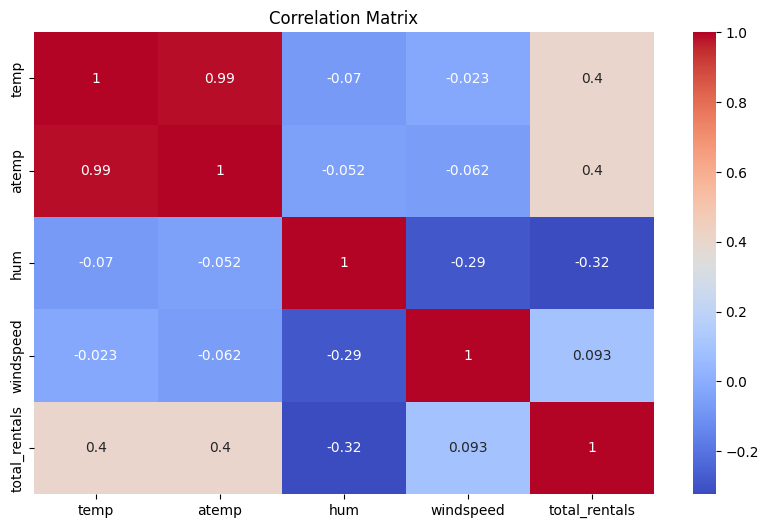

In [13]:
plt.figure(figsize=(10,6))
corr = df[['temp', 'atemp', 'hum', 'windspeed', 'total_rentals']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

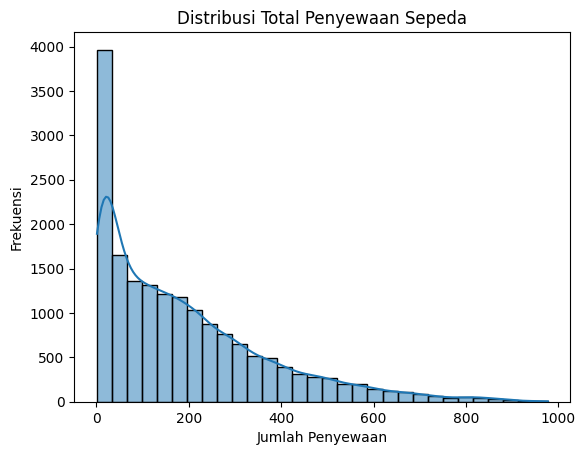

In [14]:
plt.figure()
sns.histplot(df['total_rentals'], bins=30, kde=True)
plt.title('Distribusi Total Penyewaan Sepeda')
plt.xlabel('Jumlah Penyewaan')
plt.ylabel('Frekuensi')
plt.show()

In [15]:
hourly_avg = df.groupby('hour')['total_rentals'].mean()

hourly_avg

,total_rentals
hour,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


In [16]:
weather_avg = df.groupby('weathersit')['total_rentals'].mean()

weather_avg

,total_rentals
weathersit,
Clear,204.869272
Heavy Rain/Snow,74.333333
Light Rain/Snow,111.579281
Mist,175.165493


In [17]:
workingday_avg = df.groupby('workingday')['total_rentals'].mean()

workingday_avg

,total_rentals
workingday,
0,181.405332
1,193.207754


**Insight:**
- Suhu berpengaruh positif terhadap jumlah penyewaan sepeda, sedangkan kelembapan berpengaruh negatif. Sementara, kecepatan angin memiliki pengaruh yang kecil, dan variabel temp serta atemp memiliki informasi yang hampir sama.
- Distribusi jumlah penyewaan sepeda cenderung right-skewed (miring ke kanan), menunjukkan bahwa sebagian besar penyewaan berada pada jumlah rendah hingga menengah
- Terdapat pola yang sangat jelas berdasarkan jam, jumlah penyewaan meningkat drastis pada pagi hari (sekitar pukul 07.00 - 09.00) dan mencapai puncaknya pada sore hari (sekitar pukul 17.00 - 18.00). Hal ini mengindikasikan pola penggunaan untuk aktivitas kerja
- Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan. Cuaca cerah memiliki rata-rata penyewaan tertinggi, sedangkan kondisi cuaca buruk menunjukkan penurunan drastis
- Perbedaan antara hari kerja dan non-hari kerja tidak terlalu signifikan, namun hari kerja sedikit lebih tinggi

## Visualization & Explanatory Analysis

### Pertanyaan 1:

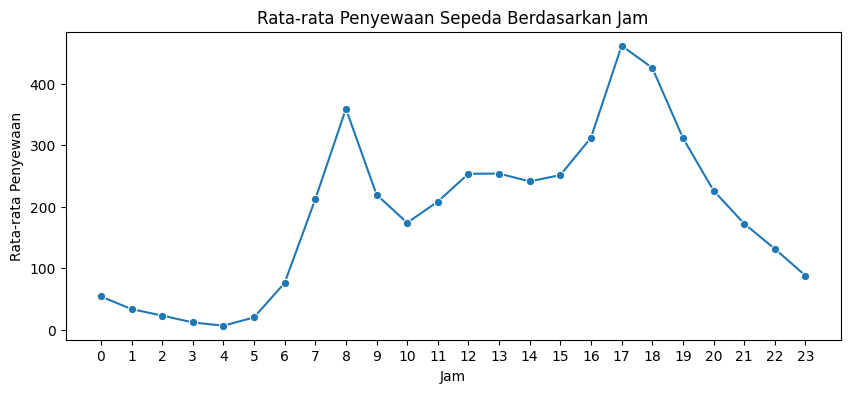

In [18]:
plt.figure(figsize=(10,4))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0,24))
plt.show()

### Pertanyaan 2:

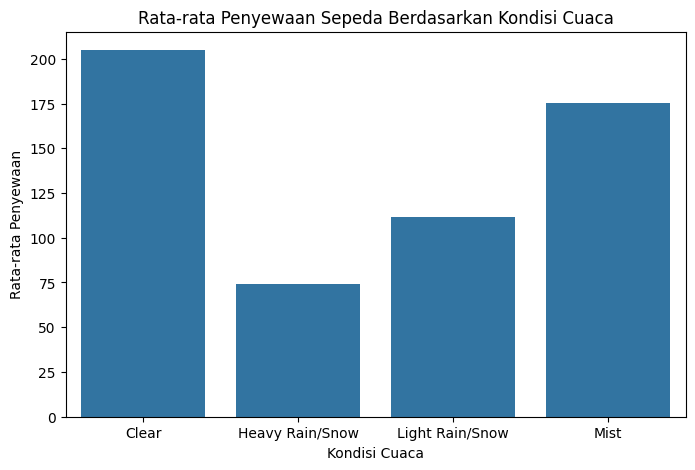

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(x=weather_avg.index, y=weather_avg.values)
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**
- Jumlah penyewaan sepeda menunjukkan pola yang jelas berdasarkan waktu, dengan puncak pada pagi dan sore hari yang mengindikasikan penggunaan untuk aktivitas kerja.
- Kondisi cuaca mempengaruhi jumlah penyewaan, di mana cuaca cerah menghasilkan jumlah tertinggi, sedangkan cuaca buruk menurunkan jumlah penyewaan secara signifikan.

## Analisis Lanjutan (Opsional)

## Conclusion

- Secara keseluruhan, waktu dan kondisi cuaca merupakan faktor utama yang mempengaruhi pola penggunaan sepeda dalam dataset ini.